# BERT 기반 한국어 동료 피드백 자동 분류: 재현성 및 일반화 실험

이 노트북은 4개의 한국어 사전학습 언어모델(Pre-trained Language Model)을 미세조정(Fine-tuning)하여
고등학교 과학 수업의 동료 피드백을 7단계로 자동 분류합니다.

## 용어 설명
- **사전학습 모델(Pre-trained Model)**: 대규모 텍스트 데이터(위키백과, 뉴스 등)로 미리 학습된 언어 모델.
  언어의 문법과 의미 구조를 이미 이해하고 있어, 소규모 데이터에서도 높은 성능을 달성할 수 있습니다.
- **미세조정(Fine-tuning)**: 사전학습된 모델을 특정 작업(여기서는 피드백 7단계 분류)에 맞게
  추가 학습하는 과정입니다. 전체 모델을 처음부터 학습하는 것보다 훨씬 효율적입니다.
- **Class-weighted Loss**: 데이터가 적은 클래스(피드백 레벨)에 더 큰 가중치를 부여하여
  모델이 소수 클래스도 올바르게 분류하도록 학습하는 기법입니다.

## 실험 개요
1. **Seed별 학습**: 3개의 다른 random seed(42, 43, 44)로 분할된 데이터셋으로 각각 학습
   - **Stratified 10-Fold CV**로 학습 및 검증 (클래스 비율 유지)
   - CV 완료 후 전체 train set으로 최종 모델 학습
2. **재현성 테스트**: 동일 test set에 대해 3회 연속 예측하여 결과 일관성 확인
3. **Cross-Seed 일반화 테스트**: 다른 seed의 test set에서 성능 유지 여부 측정
4. **종합 평가**: 성능 + 재현성 + 일반화 능력으로 최적 모델 추천

## 모델 4종
| 모델 | HuggingFace 경로 | 특징 |
|------|------------------|------|
| mBERT | bert-base-multilingual-cased | 104개 언어 다국어 모델 |
| KLUE-BERT | klue/bert-base | 한국어 특화 BERT |
| KLUE-RoBERTa | klue/roberta-base | BERT 개선 모델 (더 많은 데이터) |
| KoELECTRA | monologg/koelectra-base-v3-discriminator | 효율적 사전학습 방식 |

## 학습 파이프라인
```
Train Set → Stratified 10-Fold CV → CV 성능 기록 → 전체 Train Set 학습 → 최종 모델 → Test Set 평가
```

## 1. 환경 설정

### 라이브러리 임포트

주요 라이브러리:
- `torch`: PyTorch 딥러닝 프레임워크
- `transformers`: HuggingFace의 사전학습 모델 라이브러리 (BERT 등)
- `sklearn`: 교차검증(StratifiedKFold), 평가지표(F1, Kappa), 클래스 가중치 계산

In [49]:
import os
import random
import warnings
import json
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# HuggingFace transformers: 사전학습 BERT 모델 로드 및 미세조정 라이브러리
from transformers import (
    AutoTokenizer,                          # 텍스트→토큰 변환기
    AutoModelForSequenceClassification,     # 분류용 사전학습 모델
    get_linear_schedule_with_warmup         # 학습률 워밍업→선형감소 스케줄러
)

# scikit-learn: 교차검증 및 평가 도구
from sklearn.model_selection import StratifiedKFold          # 클래스 비율 유지 K-Fold
from sklearn.utils.class_weight import compute_class_weight  # 클래스 불균형 가중치 계산
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")

PyTorch: 2.7.0
Device: mps


### 재현성(Reproducibility) 및 디바이스 설정

딥러닝 실험의 재현성을 위해 모든 난수 생성기의 시드를 고정합니다.
또한 사용 가능한 GPU 디바이스(CUDA/MPS/CPU)를 자동 감지합니다.

- CUDA: NVIDIA GPU (RunPod 등 클라우드 환경)
- MPS: Apple Silicon GPU (M2 Max 로컬 환경)
- CPU: GPU 미사용 시 (매우 느림)

In [50]:
# 재현성을 위한 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 디바이스 설정
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# MPS 최적화 설정
if DEVICE.type == "mps":
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
    print("MPS 최적화 설정 완료")

Using device: mps
MPS 최적화 설정 완료


## 2. 실험 설정

### 실험 하이퍼파라미터 설정

BERT 미세조정(Fine-tuning)의 주요 하이퍼파라미터:
- `max_length=128`: 입력 텍스트 최대 토큰 수 (한국어 피드백은 보통 50토큰 이내)
- `batch_size=32`: 한 번에 처리하는 샘플 수
- `epochs=5`: 전체 데이터를 5회 반복 학습 (Early Stopping으로 조기 종료 가능)
- `learning_rate=2e-5`: BERT 미세조정의 표준 학습률 (매우 작은 값)
- `warmup_ratio=0.1`: 처음 10%의 학습 단계에서 학습률을 점진적으로 올림
- `patience=2`: 2 에폭 연속 성능 미개선 시 학습 중단

In [51]:
# 실험 설정
CONFIG = {
    # 데이터 경로 (seed별 파일)
    "data_path": "../data/feedback_data.xlsx",
    "seeds": [42, 43, 44],
    
    # 컬럼 이름
    "text_column": "feedback_text",
    "label_column": "label",
    
    # 모델 설정 (4종)
    "models": {
        "mBERT": "bert-base-multilingual-cased",
        "KLUE-BERT": "klue/bert-base",
        "KLUE-RoBERTa": "klue/roberta-base",
        "KoELECTRA": "monologg/koelectra-base-v3-discriminator"
    },
    
    # 학습 설정
    "max_length": 128,       # 입력 토큰 최대 길이 (피드백은 보통 50토큰 이내)
    "batch_size": 32,        # 한 번에 처리하는 샘플 수
    "epochs": 5,             # 전체 데이터 반복 학습 횟수
    "learning_rate": 2e-5,   # BERT 미세조정 표준 학습률
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "gradient_clip": 1.0,
    
    # Cross-Validation 설정
    "n_folds": 10,           # 10-Fold 교차검증
    
    # DataLoader 설정 (MPS 최적화)
    "num_workers": 0,
    "pin_memory": False,
    
    # Early stopping
    "patience": 2,           # Early Stopping: 2 에폭 미개선 시 중단
    
    # 재현성 테스트 반복 횟수
    "reproducibility_runs": 3,
    
    # 결과 저장
    "output_dir": "./results/final_experiment"
}

# 출력 디렉토리 생성
os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/figures", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/models", exist_ok=True)

print("Configuration loaded")
print(f"Models: {list(CONFIG['models'].keys())}")
print(f"Seeds: {CONFIG['seeds']}")
print(f"CV Folds: {CONFIG['n_folds']}")
print(f"Total training runs: {len(CONFIG['models']) * len(CONFIG['seeds'])} models")
print(f"Total CV folds: {len(CONFIG['models']) * len(CONFIG['seeds']) * CONFIG['n_folds']} folds")

Configuration loaded
Models: ['mBERT', 'KLUE-BERT', 'KLUE-RoBERTa', 'KoELECTRA']
Seeds: [42, 43, 44]
CV Folds: 10
Total training runs: 12 models
Total CV folds: 120 folds


## 3. 데이터 로드

### 데이터 로드

3개 seed(42, 43, 44)로 분할된 학습/테스트 데이터를 로드합니다.
각 seed는 다른 학생 조합으로 80:20 분할되어 있습니다.
같은 학생의 피드백이 학습과 테스트에 동시에 포함되지 않도록 합니다.

In [52]:
# Seed별 데이터 로드
datasets = {}

for seed in CONFIG["seeds"]:
    all_df = pd.read_excel(CONFIG["data_path"])  # data/feedback_data.xlsx (main 시트)
    df_train = all_df[all_df[f'split_seed{seed}'] == 'train'].reset_index(drop=True)
    df_test = all_df[all_df[f'split_seed{seed}'] == 'test'].reset_index(drop=True)
    
    datasets[seed] = {
        "train": df_train,
        "test": df_test
    }
    
    print(f"Seed {seed}: Train={len(df_train)}, Test={len(df_test)}")

# 클래스 수 확인
NUM_LABELS = datasets[42]["train"][CONFIG["label_column"]].nunique()
print(f"\n총 클래스 수: {NUM_LABELS}")

Seed 42: Train=1664, Test=416
Seed 43: Train=1664, Test=416
Seed 44: Train=1664, Test=416

총 클래스 수: 7


### 클래스 분포 시각화

7개 피드백 레벨(0~6)의 분포를 확인합니다.
클래스 불균형이 심한 경우(예: Level 3은 많고 Level 0은 적음),
Class-weighted Loss를 적용하여 소수 클래스의 학습을 보강합니다.

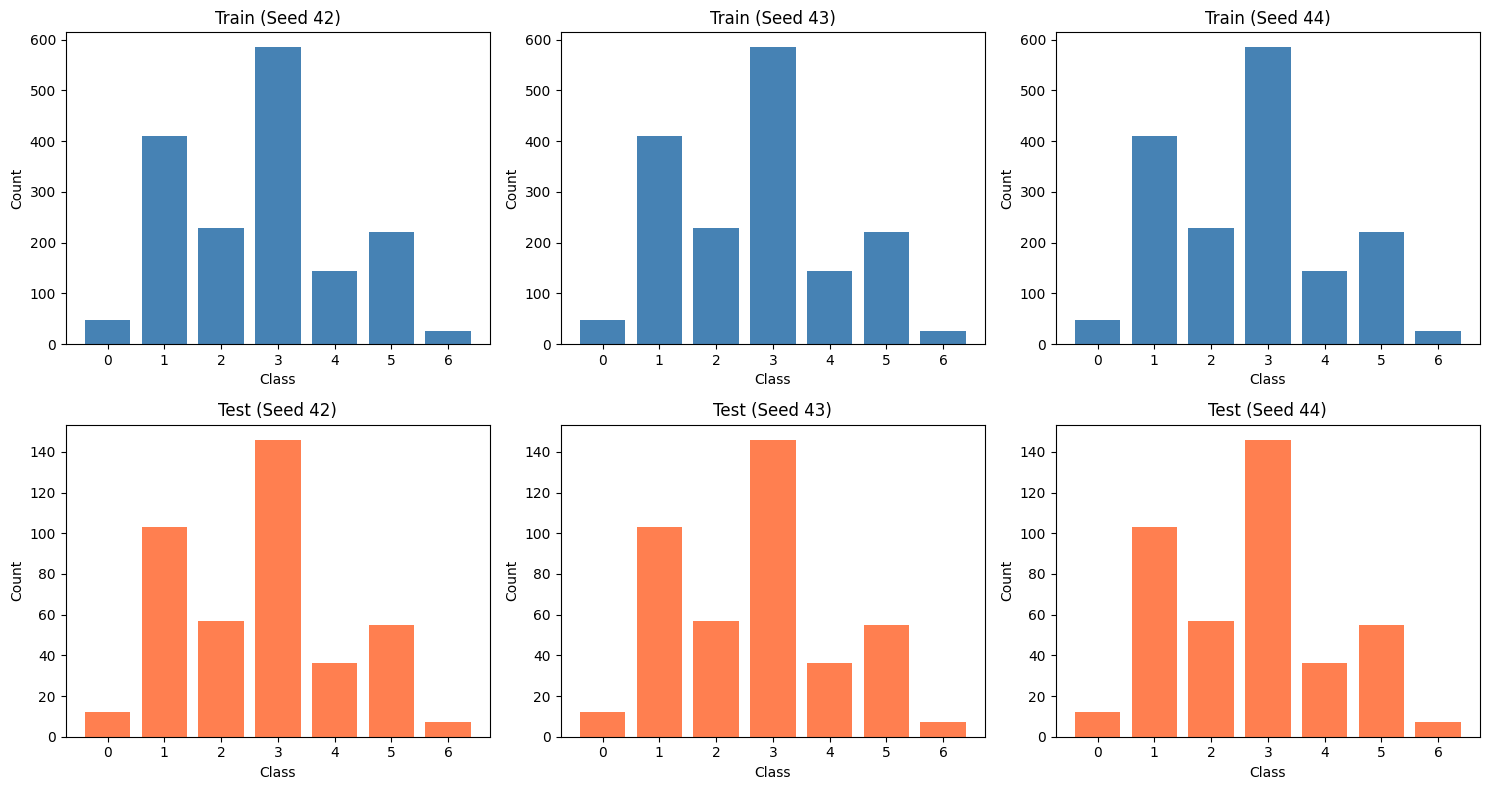

In [53]:
# 클래스 분포 확인
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, seed in enumerate(CONFIG["seeds"]):
    # Train
    train_dist = datasets[seed]["train"][CONFIG["label_column"]].value_counts().sort_index()
    axes[0, idx].bar(train_dist.index.astype(str), train_dist.values, color='steelblue')
    axes[0, idx].set_title(f"Train (Seed {seed})")
    axes[0, idx].set_xlabel("Class")
    axes[0, idx].set_ylabel("Count")
    
    # Test
    test_dist = datasets[seed]["test"][CONFIG["label_column"]].value_counts().sort_index()
    axes[1, idx].bar(test_dist.index.astype(str), test_dist.values, color='coral')
    axes[1, idx].set_title(f"Test (Seed {seed})")
    axes[1, idx].set_xlabel("Class")
    axes[1, idx].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/class_distribution_by_seed.png", dpi=150)
plt.show()

## 4. Dataset 및 학습 함수 정의

### FeedbackDataset 클래스

텍스트 데이터를 BERT 모델이 처리할 수 있는 형태로 변환합니다.
토크나이저가 각 피드백 텍스트를 다음과 같이 변환합니다:

```
원본: "실험 방법을 더 구체적으로 설명하면 좋겠어요"
→ 토큰화: [CLS] 실험 방법 ##을 더 구체 ##적 ##으로 설명 ##하면 좋 ##겠 ##어요 [SEP]
→ input_ids: [2, 3421, 5567, 1102, ...] (숫자로 변환)
→ attention_mask: [1, 1, 1, ..., 0, 0, 0] (실제 토큰=1, 패딩=0)
```

- max_length=128: 피드백 텍스트의 최대 토큰 길이
- 128 토큰 초과 시 잘림(truncation), 미만 시 패딩(padding)

In [54]:
class FeedbackDataset(Dataset):
    """피드백 분류를 위한 PyTorch Dataset"""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("FeedbackDataset class defined.")

FeedbackDataset class defined.


### 학습/평가 함수

- `train_epoch()`: 한 에폭(epoch) 동안 모델 학습
  - 순전파(Forward): 입력 → 모델 → 예측값
  - 손실 계산: 예측값과 정답의 차이 (class-weighted)
  - 역전파(Backward): 손실을 줄이는 방향으로 기울기 계산
  - 가중치 갱신: 기울기 방향으로 모델 파라미터 업데이트

- `evaluate()`: 모델 성능 평가 (학습하지 않고 예측만 수행)
  - `torch.no_grad()`: 기울기 계산을 비활성화하여 메모리 절약

In [55]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, gradient_clip=1.0):
    """한 에폭 학습"""
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    for batch in dataloader:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        loss = criterion(outputs.logits, labels)
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()
        scheduler.step()
        
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """모델 평가"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(true_labels, predictions),
        'macro_f1': f1_score(true_labels, predictions, average='macro'),
        'weighted_f1': f1_score(true_labels, predictions, average='weighted'),
        'kappa': cohen_kappa_score(true_labels, predictions)
    }
    
    return metrics, predictions, true_labels

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


### Early Stopping (조기 종료)

모델이 학습 데이터에 과적합(Overfitting)되는 것을 방지하는 기법입니다.
검증 데이터의 성능(Macro-F1)이 patience(2) 에폭 연속으로 향상되지 않으면
학습을 중단하고, 가장 좋았던 시점의 모델 가중치를 복원합니다.

In [56]:
class EarlyStopping:
    """Early stopping 구현"""
    
    def __init__(self, patience=2, mode='max'):
        self.patience = patience
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
    
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif (self.mode == 'max' and score <= self.best_score) or \
             (self.mode == 'min' and score >= self.best_score):
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
    
    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

print("EarlyStopping class defined.")

EarlyStopping class defined.


## 5. Stratified 10-Fold CV 학습 함수

### Stratified 10-Fold CV 함수

학습 데이터를 10등분하여 9개로 학습, 1개로 검증을 10회 반복합니다.
'Stratified'는 각 fold에서 원본의 클래스 비율이 유지됨을 의미합니다.

핵심 구성요소:
- **Class-weighted CrossEntropyLoss**: 소수 클래스에 높은 가중치 부여
  (예: Level 0이 50개, Level 3이 500개면 → Level 0에 10배 가중치)
  이를 통해 불균형 데이터에서도 소수 클래스를 올바르게 분류합니다.
- **AdamW Optimizer**: BERT 미세조정(Fine-tuning)의 표준 옵티마이저
- **Linear Warmup Scheduler**: 학습률을 점진적으로 올린 후 선형 감소
- **Early Stopping**: 검증 성능이 2 에폭 연속 개선되지 않으면 중단

In [57]:
def run_cross_validation(model_name, model_path, train_texts, train_labels, config, data_seed):
    """
    Stratified K-Fold Cross-Validation 실행
    
    Args:
        model_name: 모델 이름
        model_path: HuggingFace 모델 경로
        train_texts: 전체 학습 텍스트
        train_labels: 전체 학습 레이블
        config: 설정
        data_seed: 데이터 분할에 사용된 seed
    
    Returns:
        cv_results: 각 fold의 결과 리스트
        cv_summary: CV 요약 통계
    """
    
    skf = StratifiedKFold(n_splits=config["n_folds"], shuffle=True, random_state=data_seed)
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_texts, train_labels)):
        print(f"    Fold {fold + 1}/{config['n_folds']}", end=" ")
        set_seed(data_seed + fold)
        
        # 데이터 분할
        fold_train_texts = [train_texts[i] for i in train_idx]
        fold_train_labels = [train_labels[i] for i in train_idx]
        fold_val_texts = [train_texts[i] for i in val_idx]
        fold_val_labels = [train_labels[i] for i in val_idx]
        
        # 토크나이저 로드
        try:
            tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        except:
            tokenizer = AutoTokenizer.from_pretrained(model_path)
        
        # Dataset 생성
        train_dataset = FeedbackDataset(fold_train_texts, fold_train_labels, tokenizer, config["max_length"])
        val_dataset = FeedbackDataset(fold_val_texts, fold_val_labels, tokenizer, config["max_length"])
        
        # DataLoader
        train_loader = DataLoader(
            train_dataset, 
            batch_size=config["batch_size"], 
            shuffle=True,
            num_workers=config["num_workers"],
            pin_memory=config["pin_memory"]
        )
        val_loader = DataLoader(
            val_dataset, 
            batch_size=config["batch_size"],
            num_workers=config["num_workers"],
            pin_memory=config["pin_memory"]
        )
        
        # 모델 로드
        try:
            model = AutoModelForSequenceClassification.from_pretrained(
                model_path, 
                num_labels=NUM_LABELS,
                trust_remote_code=True
            )
        except:
            model = AutoModelForSequenceClassification.from_pretrained(
                model_path, 
                num_labels=NUM_LABELS
            )
        model.to(DEVICE)
        
        # 클래스 가중치 계산 (불균형 데이터 핵심 처리)
        # 소수 클래스에 높은 가중치 → 모델이 소수 클래스도 올바르게 학습
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(fold_train_labels),
            y=fold_train_labels
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)  # 가중치 적용 손실함수
        
        # Optimizer & Scheduler
        optimizer = AdamW(
            model.parameters(), 
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"]
        )
        
        total_steps = len(train_loader) * config["epochs"]
        warmup_steps = int(total_steps * config["warmup_ratio"])
        scheduler = get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Early stopping
        early_stopping = EarlyStopping(patience=config["patience"], mode='max')
        
        # 학습
        for epoch in range(config["epochs"]):
            train_loss, train_acc = train_epoch(
                model, train_loader, optimizer, scheduler, criterion, DEVICE, config["gradient_clip"]
            )
            
            val_metrics, _, _ = evaluate(model, val_loader, criterion, DEVICE)
            
            early_stopping(val_metrics['macro_f1'], model)
            if early_stopping.early_stop:
                break
        
        # Best 모델 로드 후 최종 평가
        early_stopping.load_best_model(model)
        model.to(DEVICE)
        val_metrics, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        
        fold_results.append(val_metrics)
        print(f"→ Acc: {val_metrics['accuracy']:.4f}, F1: {val_metrics['macro_f1']:.4f}")
        
        # 메모리 정리
        del model, optimizer, scheduler, tokenizer
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        elif torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # CV 결과 요약
    cv_summary = {
        'accuracy_mean': np.mean([r['accuracy'] for r in fold_results]),
        'accuracy_std': np.std([r['accuracy'] for r in fold_results]),
        'macro_f1_mean': np.mean([r['macro_f1'] for r in fold_results]),
        'macro_f1_std': np.std([r['macro_f1'] for r in fold_results]),
        'weighted_f1_mean': np.mean([r['weighted_f1'] for r in fold_results]),
        'weighted_f1_std': np.std([r['weighted_f1'] for r in fold_results]),
        'kappa_mean': np.mean([r['kappa'] for r in fold_results]),
        'kappa_std': np.std([r['kappa'] for r in fold_results])
    }
    
    return fold_results, cv_summary

print("Cross-validation function defined.")

Cross-validation function defined.


### 전체 데이터 학습 함수

CV가 완료된 후, 전체 학습 데이터(fold 분할 없이)로 최종 모델을 학습합니다.
이 모델이 실제 테스트 세트 평가와 추후 예측에 사용됩니다.

In [58]:
def train_final_model(model_name, model_path, train_texts, train_labels, config, data_seed):
    """
    전체 train set으로 최종 모델 학습
    
    Returns:
        model, tokenizer
    """
    set_seed(data_seed)
    
    # 토크나이저 로드
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    except:
        tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    # Dataset 생성
    train_dataset = FeedbackDataset(train_texts, train_labels, tokenizer, config["max_length"])
    
    # DataLoader
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config["batch_size"], 
        shuffle=True,
        num_workers=config["num_workers"],
        pin_memory=config["pin_memory"]
    )
    
    # 모델 로드
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, 
            num_labels=NUM_LABELS,
            trust_remote_code=True
        )
    except:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, 
            num_labels=NUM_LABELS
        )
    model.to(DEVICE)
    
    # Class weight 계산
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Optimizer & Scheduler
    optimizer = AdamW(
        model.parameters(), 
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    
    total_steps = len(train_loader) * config["epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    # 학습 (전체 epoch 수행)
    for epoch in range(config["epochs"]):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, scheduler, criterion, DEVICE, config["gradient_clip"]
        )
    
    return model, tokenizer

print("Final model training function defined.")

Final model training function defined.


In [59]:
def evaluate_on_test(model, tokenizer, test_texts, test_labels, config):
    """
    Test set에서 모델 평가
    """
    test_dataset = FeedbackDataset(test_texts, test_labels, tokenizer, config["max_length"])
    test_loader = DataLoader(
        test_dataset, 
        batch_size=config["batch_size"],
        num_workers=config["num_workers"],
        pin_memory=config["pin_memory"]
    )
    
    # 더미 criterion (평가용)
    criterion = nn.CrossEntropyLoss()
    
    metrics, predictions, true_labels = evaluate(model, test_loader, criterion, DEVICE)
    
    return metrics, predictions, true_labels

print("Test evaluation function defined.")

Test evaluation function defined.


## 6. 단계 1: Seed별 10-Fold CV 학습 + 최종 모델 생성

In [60]:
# 결과 저장용
trained_models = {}  # {(model_name, seed): (model, tokenizer)}
cv_results_all = []  # CV 결과
test_results_all = []  # Test 결과

total_combinations = len(CONFIG["models"]) * len(CONFIG["seeds"])
current = 0

print("="*70)
print("단계 1: Stratified 10-Fold CV 학습 + 최종 모델 생성")
print(f"총 {total_combinations}개 모델 × {CONFIG['n_folds']} folds = {total_combinations * CONFIG['n_folds']} CV 학습")
print("="*70)

단계 1: Stratified 10-Fold CV 학습 + 최종 모델 생성
총 12개 모델 × 10 folds = 120 CV 학습


### 메인 학습 루프

4개 모델 × 3개 seed = 12개 조합에 대해 순차적으로 학습합니다.
각 조합마다:
1. 사전학습 모델(Pre-trained Model)을 HuggingFace에서 다운로드
2. 10-Fold CV로 성능 측정
3. 전체 학습 데이터로 최종 모델 학습
4. 고정 테스트 세트에서 성능 평가

이 과정에서 미세조정(Fine-tuning)이 이루어집니다.
미세조정이란 사전학습된 모델을 우리의 피드백 분류 작업에 맞게 추가 학습하는 것입니다.

In [61]:
for model_name, model_path in CONFIG["models"].items():
    for seed in CONFIG["seeds"]:
        current += 1
        print(f"\n[{current}/{total_combinations}] {model_name} - Seed {seed}")
        print("-"*50)
        
        try:
            train_data = datasets[seed]["train"]
            test_data = datasets[seed]["test"]
            
            train_texts = train_data[CONFIG["text_column"]].tolist()
            train_labels = train_data[CONFIG["label_column"]].tolist()
            test_texts = test_data[CONFIG["text_column"]].tolist()
            test_labels = test_data[CONFIG["label_column"]].tolist()
            
            # 1. 10-Fold CV 수행
            print("  [CV 학습]")
            fold_results, cv_summary = run_cross_validation(
                model_name, model_path, train_texts, train_labels, CONFIG, seed
            )
            
            print(f"  [CV 결과] Acc: {cv_summary['accuracy_mean']:.4f} (±{cv_summary['accuracy_std']:.4f}), "
                  f"F1: {cv_summary['macro_f1_mean']:.4f} (±{cv_summary['macro_f1_std']:.4f})")
            
            # CV 결과 저장
            cv_result = {
                "model": model_name,
                "seed": seed,
                **cv_summary
            }
            cv_results_all.append(cv_result)
            
            # 2. 전체 train set으로 최종 모델 학습
            print("  [최종 모델 학습]")
            model, tokenizer = train_final_model(
                model_name, model_path, train_texts, train_labels, CONFIG, seed
            )
            
            # 3. Test set 평가
            print("  [Test 평가]")
            test_metrics, predictions, true_labels = evaluate_on_test(
                model, tokenizer, test_texts, test_labels, CONFIG
            )
            
            print(f"  [Test 결과] Acc: {test_metrics['accuracy']:.4f}, "
                  f"F1: {test_metrics['macro_f1']:.4f}, Kappa: {test_metrics['kappa']:.4f}")
            
            # Test 결과 저장
            test_result = {
                "model": model_name,
                "train_seed": seed,
                "test_seed": seed,
                "accuracy": test_metrics["accuracy"],
                "macro_f1": test_metrics["macro_f1"],
                "weighted_f1": test_metrics["weighted_f1"],
                "kappa": test_metrics["kappa"]
            }
            test_results_all.append(test_result)
            
            # 모델 저장
            trained_models[(model_name, seed)] = (model, tokenizer)
            
            save_dir = f"{CONFIG['output_dir']}/models/{model_name}_seed{seed}"
            os.makedirs(save_dir, exist_ok=True)
            model.save_pretrained(save_dir)
            tokenizer.save_pretrained(save_dir)
            print(f"  [모델 저장] {save_dir}")
            
            # 메모리 정리
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
            elif torch.cuda.is_available():
                torch.cuda.empty_cache()
                
        except Exception as e:
            print(f"  Error: {e}")
            import traceback
            traceback.print_exc()
            continue

print("\n" + "="*70)
print("단계 1 완료")
print("="*70)


[1/12] mBERT - Seed 42
--------------------------------------------------
  [CV 학습]
    Fold 1/10 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ Acc: 0.9461, F1: 0.9059
    Fold 2/10 

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ Acc: 0.9281, F1: 0.9221
    Fold 3/10 

...

→ Acc: 0.8916, F1: 0.8282
    Fold 10/10 

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ Acc: 0.8795, F1: 0.8129
  [CV 결과] Acc: 0.8666 (±0.0290), F1: 0.8003 (±0.0385)
  [최종 모델 학습]


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  [Test 평가]
  [Test 결과] Acc: 0.9087, F1: 0.8618, Kappa: 0.8810
  [모델 저장] ./results/final_experiment/models/KoELECTRA_seed44

단계 1 완료


In [62]:
# CV 결과 저장
cv_df = pd.DataFrame(cv_results_all)
cv_df.to_csv(f"{CONFIG['output_dir']}/cv_results.csv", index=False)

print("=== 10-Fold CV 결과 ===")
print(cv_df[["model", "seed", "accuracy_mean", "accuracy_std", "macro_f1_mean", "macro_f1_std"]].to_string(index=False))

=== 10-Fold CV 결과 ===
       model  seed  accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
       mBERT    42       0.905631      0.028764       0.852734      0.059567
       mBERT    43       0.915854      0.027058       0.865945      0.036788
       mBERT    44       0.900245      0.030228       0.842163      0.068169
   KLUE-BERT    42       0.945913      0.016146       0.913933      0.044205
   KLUE-BERT    43       0.939290      0.022874       0.906574      0.036629
   KLUE-BERT    44       0.934510      0.012659       0.902105      0.021088
KLUE-RoBERTa    42       0.931491      0.019627       0.890227      0.039106
KLUE-RoBERTa    43       0.937497      0.016630       0.907606      0.022468
KLUE-RoBERTa    44       0.932119      0.014842       0.904686      0.024464
   KoELECTRA    42       0.861157      0.037712       0.779009      0.077770
   KoELECTRA    43       0.868361      0.037772       0.793807      0.061651
   KoELECTRA    44       0.866575      0.028990       

In [63]:
# Test 결과 저장
test_df = pd.DataFrame(test_results_all)
test_df.to_csv(f"{CONFIG['output_dir']}/test_results.csv", index=False)

print("=== Test Set 결과 ===")
print(test_df.to_string(index=False))

=== Test Set 결과 ===
       model  train_seed  test_seed  accuracy  macro_f1  weighted_f1    kappa
       mBERT          42         42  0.913462  0.878928     0.914282 0.888143
       mBERT          43         43  0.925481  0.892553     0.923870 0.903062
       mBERT          44         44  0.927885  0.894283     0.926972 0.906319
   KLUE-BERT          42         42  0.923077  0.903939     0.923215 0.900308
   KLUE-BERT          43         43  0.930288  0.893619     0.927977 0.909146
   KLUE-BERT          44         44  0.966346  0.940875     0.965958 0.956274
KLUE-RoBERTa          42         42  0.942308  0.921152     0.942172 0.925222
KLUE-RoBERTa          43         43  0.927885  0.889233     0.925278 0.905932
KLUE-RoBERTa          44         44  0.939904  0.902517     0.939496 0.922007
   KoELECTRA          42         42  0.850962  0.783399     0.850098 0.807465
   KoELECTRA          43         43  0.879808  0.832084     0.875398 0.843092
   KoELECTRA          44         44  0.90865

## 7. 단계 2: 재현성 테스트 (Reproducibility)

### 예측 함수 정의

학습된 모델을 사용하여 새로운 텍스트에 대한 분류 예측을 수행하는 함수입니다.
`model.eval()` 모드에서 실행되며, dropout이 비활성화되어 결정적 예측을 합니다.

In [64]:
def predict_with_model(model, tokenizer, texts, config):
    """모델로 예측 수행"""
    model.eval()
    
    dataset = FeedbackDataset(
        texts, 
        [0] * len(texts),  # 더미 레이블
        tokenizer, 
        config["max_length"]
    )
    dataloader = DataLoader(
        dataset, 
        batch_size=config["batch_size"],
        num_workers=config["num_workers"],
        pin_memory=config["pin_memory"]
    )
    
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
    
    return predictions

print("Prediction function defined.")

Prediction function defined.


### 재현성 테스트 실행

동일한 모델, 동일한 테스트 데이터에 대해 3회 연속 예측을 수행합니다.
딥러닝 모델은 GPU 연산의 비결정성으로 인해 매번 다른 결과를 낼 수 있으므로,
`model.eval()` 모드에서의 예측 일관성을 확인합니다.

- **Agreement Rate**: 3회 예측 중 동일한 결과의 비율 (100%가 이상적)

In [65]:
# 재현성 테스트: 같은 test set에 대해 3회 연속 예측
reproducibility_results = []

print("="*70)
print("단계 2: 재현성 테스트")
print(f"각 모델에 대해 동일 test set을 {CONFIG['reproducibility_runs']}회 예측")
print("="*70)

for (model_name, seed), (model, tokenizer) in tqdm(trained_models.items(), desc="재현성 테스트"):
    test_data = datasets[seed]["test"]
    test_texts = test_data[CONFIG["text_column"]].tolist()
    true_labels = test_data[CONFIG["label_column"]].tolist()
    
    # 3회 반복 예측
    all_predictions = []
    for run in range(CONFIG["reproducibility_runs"]):
        preds = predict_with_model(model, tokenizer, test_texts, CONFIG)
        all_predictions.append(preds)
    
    # 재현성 분석
    all_predictions = np.array(all_predictions)  # (runs, samples)
    
    # 각 샘플에 대해 모든 예측이 일치하는지 확인
    agreement = np.all(all_predictions == all_predictions[0], axis=0)
    agreement_rate = np.mean(agreement)
    
    # 각 run의 정확도
    run_accuracies = [accuracy_score(true_labels, all_predictions[i]) for i in range(CONFIG["reproducibility_runs"])]
    run_f1s = [f1_score(true_labels, all_predictions[i], average='macro') for i in range(CONFIG["reproducibility_runs"])]
    
    result = {
        "model": model_name,
        "seed": seed,
        "agreement_rate": agreement_rate,
        "accuracy_mean": np.mean(run_accuracies),
        "accuracy_std": np.std(run_accuracies),
        "macro_f1_mean": np.mean(run_f1s),
        "macro_f1_std": np.std(run_f1s),
        "run1_acc": run_accuracies[0],
        "run2_acc": run_accuracies[1],
        "run3_acc": run_accuracies[2]
    }
    reproducibility_results.append(result)

print("\n단계 2 완료")

단계 2: 재현성 테스트
각 모델에 대해 동일 test set을 3회 예측


재현성 테스트: 100%|██████████| 12/12 [01:56<00:00,  9.73s/it]


단계 2 완료


In [66]:
# 재현성 결과 저장
repro_df = pd.DataFrame(reproducibility_results)
repro_df.to_csv(f"{CONFIG['output_dir']}/reproducibility.csv", index=False)

print("=== 재현성 테스트 결과 ===")
print(repro_df[["model", "seed", "agreement_rate", "accuracy_mean", "accuracy_std"]].to_string(index=False))

=== 재현성 테스트 결과 ===
       model  seed  agreement_rate  accuracy_mean  accuracy_std
       mBERT    42             1.0       0.913462  0.000000e+00
       mBERT    43             1.0       0.925481  0.000000e+00
       mBERT    44             1.0       0.927885  0.000000e+00
   KLUE-BERT    42             1.0       0.923077  1.110223e-16
   KLUE-BERT    43             1.0       0.930288  0.000000e+00
   KLUE-BERT    44             1.0       0.966346  0.000000e+00
KLUE-RoBERTa    42             1.0       0.942308  1.110223e-16
KLUE-RoBERTa    43             1.0       0.927885  0.000000e+00
KLUE-RoBERTa    44             1.0       0.939904  0.000000e+00
   KoELECTRA    42             1.0       0.850962  0.000000e+00
   KoELECTRA    43             1.0       0.879808  1.110223e-16
   KoELECTRA    44             1.0       0.908654  0.000000e+00


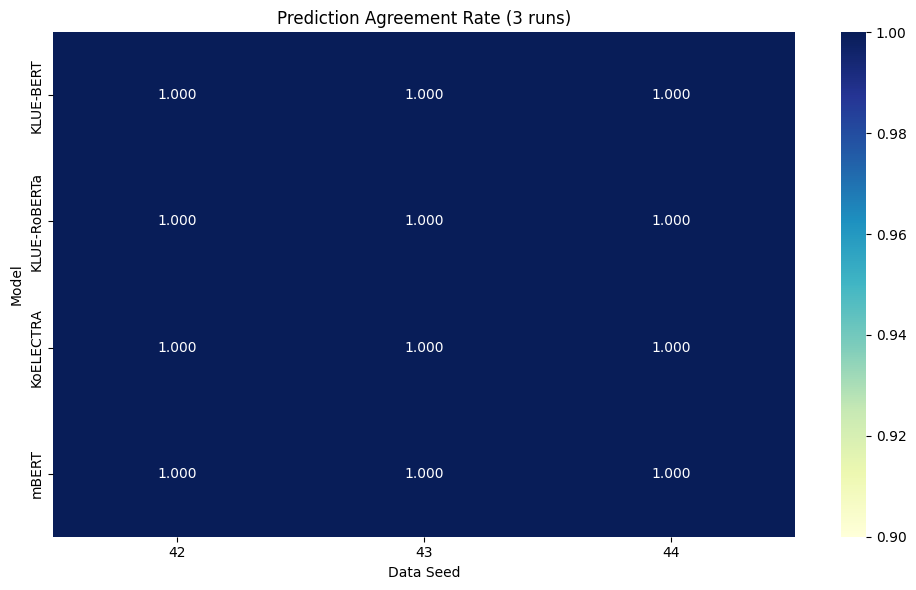

In [67]:
# 재현성 시각화: Agreement Rate 히트맵
pivot_agreement = repro_df.pivot(index="model", columns="seed", values="agreement_rate")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_agreement, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.9, vmax=1.0)
plt.title("Prediction Agreement Rate (3 runs)")
plt.xlabel("Data Seed")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/reproducibility_heatmap.png", dpi=150)
plt.show()

## 8. 단계 3: Cross-Seed 일반화 테스트

### Cross-Seed 일반화 테스트 실행

각 모델이 학습에 사용한 seed(예: seed 42)와 다른 seed(43, 44)의 
테스트 세트에서도 유사한 성능을 유지하는지 확인합니다.

- **Same-seed**: 학습과 같은 seed의 테스트 세트 (기본 성능)
- **Cross-seed**: 다른 seed의 테스트 세트 (일반화 성능)
- 성능 하락이 작을수록 일반화 능력이 우수합니다.

In [68]:
# Cross-Seed 테스트: 다른 seed의 test set에서 성능 측정
cross_seed_results = []

print("="*70)
print("단계 3: Cross-Seed 일반화 테스트")
print("각 모델이 다른 seed의 test set에서 어떤 성능을 보이는지 확인")
print("="*70)

for (model_name, train_seed), (model, tokenizer) in tqdm(trained_models.items(), desc="Cross-Seed 테스트"):
    for test_seed in CONFIG["seeds"]:
        test_data = datasets[test_seed]["test"]
        test_texts = test_data[CONFIG["text_column"]].tolist()
        true_labels = test_data[CONFIG["label_column"]].tolist()
        
        # 예측
        predictions = predict_with_model(model, tokenizer, test_texts, CONFIG)
        
        # 성능 계산
        acc = accuracy_score(true_labels, predictions)
        f1 = f1_score(true_labels, predictions, average='macro')
        kappa = cohen_kappa_score(true_labels, predictions)
        
        result = {
            "model": model_name,
            "train_seed": train_seed,
            "test_seed": test_seed,
            "is_same_seed": train_seed == test_seed,
            "accuracy": acc,
            "macro_f1": f1,
            "kappa": kappa
        }
        cross_seed_results.append(result)

print("\n단계 3 완료")

단계 3: Cross-Seed 일반화 테스트
각 모델이 다른 seed의 test set에서 어떤 성능을 보이는지 확인


Cross-Seed 테스트: 100%|██████████| 12/12 [01:29<00:00,  7.46s/it]


단계 3 완료


In [69]:
# Cross-Seed 결과 저장
cross_df = pd.DataFrame(cross_seed_results)
cross_df.to_csv(f"{CONFIG['output_dir']}/cross_seed_generalization.csv", index=False)

print("=== Cross-Seed 일반화 테스트 결과 ===")
print(cross_df.to_string(index=False))

=== Cross-Seed 일반화 테스트 결과 ===
       model  train_seed  test_seed  is_same_seed  accuracy  macro_f1    kappa
       mBERT          42         42          True  0.913462  0.878928 0.888143
       mBERT          42         43         False  0.966346  0.960340 0.956345
       mBERT          42         44         False  0.963942  0.951383 0.953298
       mBERT          43         42         False  0.968750  0.968939 0.959512
       mBERT          43         43          True  0.925481  0.892553 0.903062
       mBERT          43         44         False  0.980769  0.982407 0.975069
       mBERT          44         42         False  0.973558  0.974603 0.965686
       mBERT          44         43         False  0.973558  0.962648 0.965632
       mBERT          44         44          True  0.927885  0.894283 0.906319
   KLUE-BERT          42         42          True  0.923077  0.903939 0.900308
   KLUE-BERT          42         43         False  0.971154  0.970003 0.962579
   KLUE-BERT          

In [70]:
# Same-seed vs Cross-seed 성능 비교
same_seed = cross_df[cross_df["is_same_seed"] == True]
diff_seed = cross_df[cross_df["is_same_seed"] == False]

comparison = []
for model_name in CONFIG["models"].keys():
    same = same_seed[same_seed["model"] == model_name]
    diff = diff_seed[diff_seed["model"] == model_name]
    
    comparison.append({
        "model": model_name,
        "same_seed_acc": same["accuracy"].mean(),
        "cross_seed_acc": diff["accuracy"].mean(),
        "acc_drop": same["accuracy"].mean() - diff["accuracy"].mean(),
        "same_seed_f1": same["macro_f1"].mean(),
        "cross_seed_f1": diff["macro_f1"].mean(),
        "f1_drop": same["macro_f1"].mean() - diff["macro_f1"].mean()
    })

comparison_df = pd.DataFrame(comparison)
print("\n=== Same-Seed vs Cross-Seed 성능 비교 ===")
print(comparison_df.to_string(index=False))


=== Same-Seed vs Cross-Seed 성능 비교 ===
       model  same_seed_acc  cross_seed_acc  acc_drop  same_seed_f1  cross_seed_f1   f1_drop
       mBERT       0.922276        0.971154 -0.048878      0.888588       0.966720 -0.078132
   KLUE-BERT       0.939904        0.978766 -0.038862      0.912811       0.978392 -0.065581
KLUE-RoBERTa       0.936699        0.975561 -0.038862      0.904301       0.970404 -0.066103
   KoELECTRA       0.879808        0.919071 -0.039263      0.825770       0.891206 -0.065436


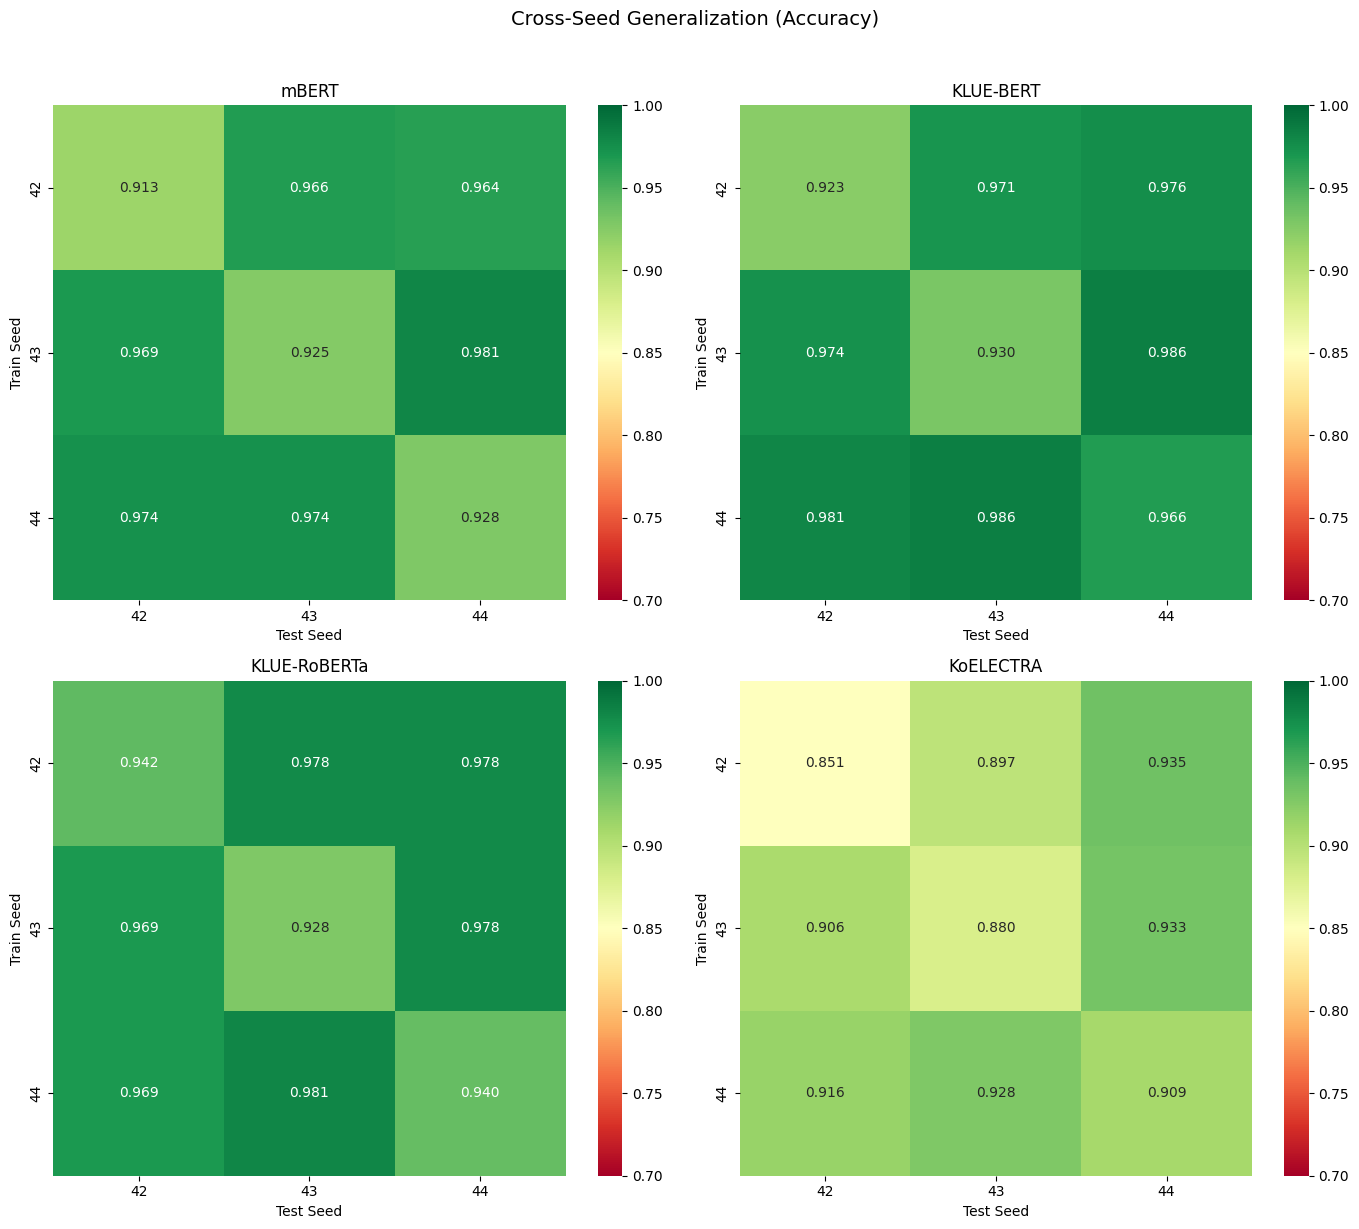

In [71]:
# Cross-Seed 성능 매트릭스 시각화 (모델별)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, model_name in enumerate(CONFIG["models"].keys()):
    model_data = cross_df[cross_df["model"] == model_name]
    pivot = model_data.pivot(index="train_seed", columns="test_seed", values="accuracy")
    
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", 
                vmin=0.7, vmax=1.0, ax=axes[idx])
    axes[idx].set_title(f"{model_name}")
    axes[idx].set_xlabel("Test Seed")
    axes[idx].set_ylabel("Train Seed")

plt.suptitle("Cross-Seed Generalization (Accuracy)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/cross_seed_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. 종합 분석 및 모델 랭킹

### 종합 모델 랭킹

CV 평균 성능, Test 평균 성능, 재현성(Agreement Rate), 일반화(Cross-Seed 성능 유지율)를
종합하여 각 모델에 0~1 범위의 종합 점수를 부여합니다.

종합 점수 = 0.3×CV_성능 + 0.3×Test_성능 + 0.2×재현성 + 0.2×일반화

In [72]:
# 모델별 종합 성능 계산
model_ranking = []

for model_name in CONFIG["models"].keys():
    # 1. CV 평균 성능
    model_cv = cv_df[cv_df["model"] == model_name]
    cv_accuracy = model_cv["accuracy_mean"].mean()
    cv_accuracy_std = model_cv["accuracy_std"].mean()
    cv_f1 = model_cv["macro_f1_mean"].mean()
    cv_f1_std = model_cv["macro_f1_std"].mean()
    
    # 2. Test 평균 성능
    model_test = test_df[test_df["model"] == model_name]
    test_accuracy = model_test["accuracy"].mean()
    test_accuracy_std = model_test["accuracy"].std()
    test_f1 = model_test["macro_f1"].mean()
    test_kappa = model_test["kappa"].mean()
    
    # 3. 재현성
    model_repro = repro_df[repro_df["model"] == model_name]
    avg_agreement = model_repro["agreement_rate"].mean()
    
    # 4. 일반화 성능 (cross-seed performance drop)
    model_comp = comparison_df[comparison_df["model"] == model_name]
    acc_drop = model_comp["acc_drop"].values[0]
    cross_seed_acc = model_comp["cross_seed_acc"].values[0]
    
    # 5. 종합 점수 계산
    overall_score = (
        test_accuracy * 0.25 +
        test_f1 * 0.25 +
        avg_agreement * 0.15 +
        cross_seed_acc * 0.20 +
        (1 - test_accuracy_std) * 0.05 +
        (1 - abs(acc_drop)) * 0.10
    )
    
    model_ranking.append({
        "model": model_name,
        "cv_accuracy": cv_accuracy,
        "cv_accuracy_std": cv_accuracy_std,
        "cv_macro_f1": cv_f1,
        "cv_macro_f1_std": cv_f1_std,
        "test_accuracy": test_accuracy,
        "test_accuracy_std": test_accuracy_std,
        "test_macro_f1": test_f1,
        "test_kappa": test_kappa,
        "agreement_rate": avg_agreement,
        "cross_seed_acc": cross_seed_acc,
        "acc_drop": acc_drop,
        "overall_score": overall_score
    })

ranking_df = pd.DataFrame(model_ranking)
ranking_df = ranking_df.sort_values("overall_score", ascending=False).reset_index(drop=True)
ranking_df["rank"] = range(1, len(ranking_df) + 1)

print("=" * 70)
print("모델 종합 랭킹")
print("=" * 70)
print(ranking_df[["rank", "model", "cv_accuracy", "test_accuracy", "test_macro_f1", 
                  "agreement_rate", "cross_seed_acc", "overall_score"]].to_string(index=False))

모델 종합 랭킹
 rank        model  cv_accuracy  test_accuracy  test_macro_f1  agreement_rate  cross_seed_acc  overall_score
    1    KLUE-BERT     0.939905       0.939904       0.912811             1.0        0.978766       0.953887
    2 KLUE-RoBERTa     0.933702       0.936699       0.904301             1.0        0.975561       0.951089
    3        mBERT     0.907243       0.922276       0.888588             1.0        0.971154       0.941673
    4    KoELECTRA     0.865364       0.879808       0.825770             1.0        0.919071       0.904840


In [73]:
# 랭킹 저장
ranking_df.to_csv(f"{CONFIG['output_dir']}/model_ranking.csv", index=False)

# Best 모델 정보
best_model = ranking_df.iloc[0]
print("\n" + "=" * 70)
print("추천 모델")
print("=" * 70)
print(f"\n  Best Model: {best_model['model']}")
print(f"\n  CV 성능:")
print(f"    - CV 정확도: {best_model['cv_accuracy']:.4f} (±{best_model['cv_accuracy_std']:.4f})")
print(f"    - CV Macro-F1: {best_model['cv_macro_f1']:.4f} (±{best_model['cv_macro_f1_std']:.4f})")
print(f"\n  Test 성능:")
print(f"    - Test 정확도: {best_model['test_accuracy']:.4f} (±{best_model['test_accuracy_std']:.4f})")
print(f"    - Test Macro-F1: {best_model['test_macro_f1']:.4f}")
print(f"    - Test Kappa: {best_model['test_kappa']:.4f}")
print(f"\n  재현성:")
print(f"    - 예측 일치율: {best_model['agreement_rate']:.4f}")
print(f"\n  일반화 능력:")
print(f"    - Cross-Seed 정확도: {best_model['cross_seed_acc']:.4f}")
print(f"    - 성능 하락폭: {best_model['acc_drop']:.4f}")
print(f"\n  종합 점수: {best_model['overall_score']:.4f}")


추천 모델

  Best Model: KLUE-BERT

  CV 성능:
    - CV 정확도: 0.9399 (±0.0172)
    - CV Macro-F1: 0.9075 (±0.0340)

  Test 성능:
    - Test 정확도: 0.9399 (±0.0232)
    - Test Macro-F1: 0.9128
    - Test Kappa: 0.9219

  재현성:
    - 예측 일치율: 1.0000

  일반화 능력:
    - Cross-Seed 정확도: 0.9788
    - 성능 하락폭: -0.0389

  종합 점수: 0.9539


## 10. 결과 시각화

### 시각화 1-2: CV vs Test 성능 비교, Seed별 성능

CV 성능과 Test 성능의 차이가 크면 과적합(Overfitting)을 의심할 수 있습니다.
3개 seed에서의 성능 편차가 작을수록 모델이 안정적입니다.

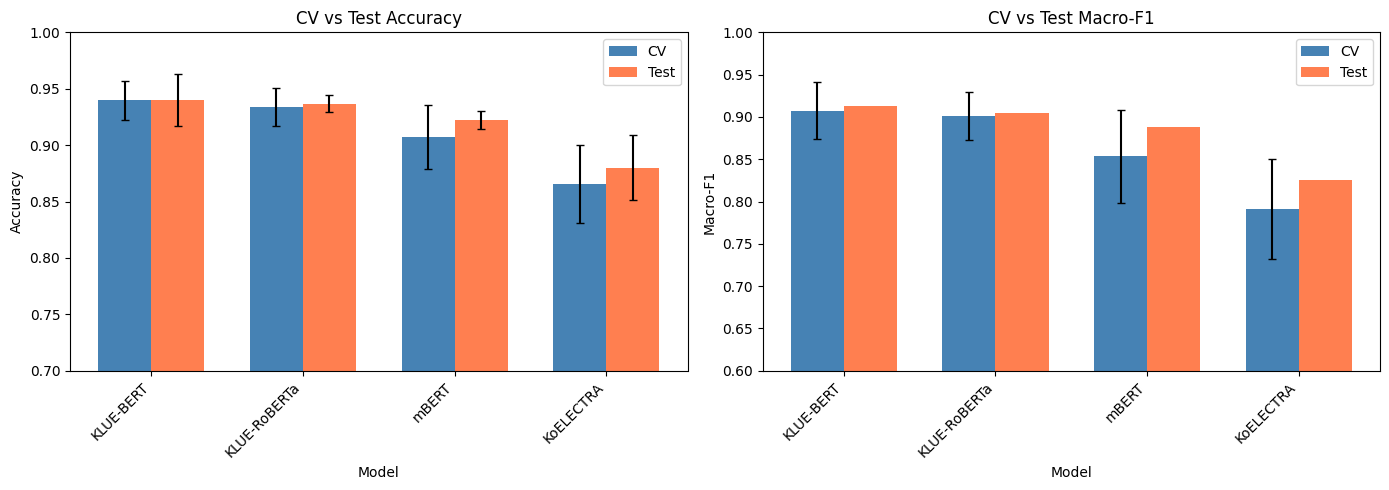

In [74]:
# 1. CV vs Test 성능 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ranking_df["model"].tolist()
x = np.arange(len(models))
width = 0.35

# Accuracy
axes[0].bar(x - width/2, ranking_df["cv_accuracy"], width, label='CV', color='steelblue', 
            yerr=ranking_df["cv_accuracy_std"], capsize=3)
axes[0].bar(x + width/2, ranking_df["test_accuracy"], width, label='Test', color='coral',
            yerr=ranking_df["test_accuracy_std"], capsize=3)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("CV vs Test Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)

# Macro-F1
axes[1].bar(x - width/2, ranking_df["cv_macro_f1"], width, label='CV', color='steelblue',
            yerr=ranking_df["cv_macro_f1_std"], capsize=3)
axes[1].bar(x + width/2, ranking_df["test_macro_f1"], width, label='Test', color='coral')
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("CV vs Test Macro-F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/cv_vs_test.png", dpi=150)
plt.show()

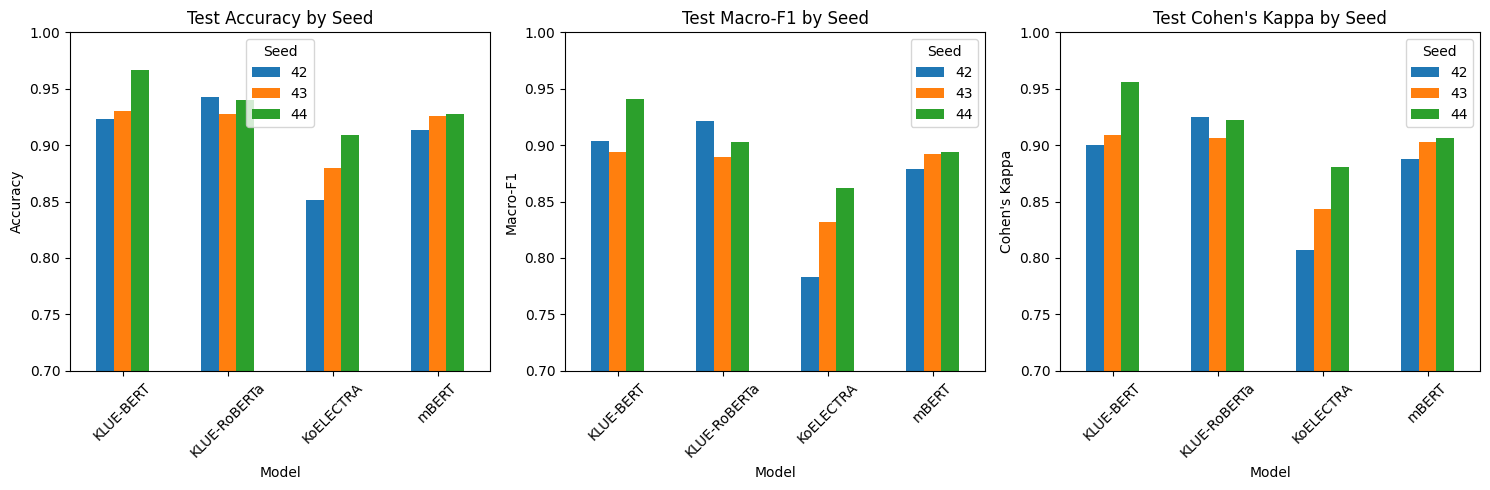

In [75]:
# 2. Seed별 Test 성능 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ["accuracy", "macro_f1", "kappa"]
titles = ["Accuracy", "Macro-F1", "Cohen's Kappa"]

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    pivot = test_df.pivot(index="model", columns="train_seed", values=metric)
    pivot.plot(kind="bar", ax=axes[idx], rot=45)
    axes[idx].set_title(f"Test {title} by Seed")
    axes[idx].set_xlabel("Model")
    axes[idx].set_ylabel(title)
    axes[idx].legend(title="Seed")
    axes[idx].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/test_by_seed.png", dpi=150)
plt.show()

### 시각화 3-4: 모델 종합 비교 및 랭킹

모든 평가 지표(CV 성능, Test 성능, 재현성, 일반화)를 종합한 최종 모델 랭킹입니다.

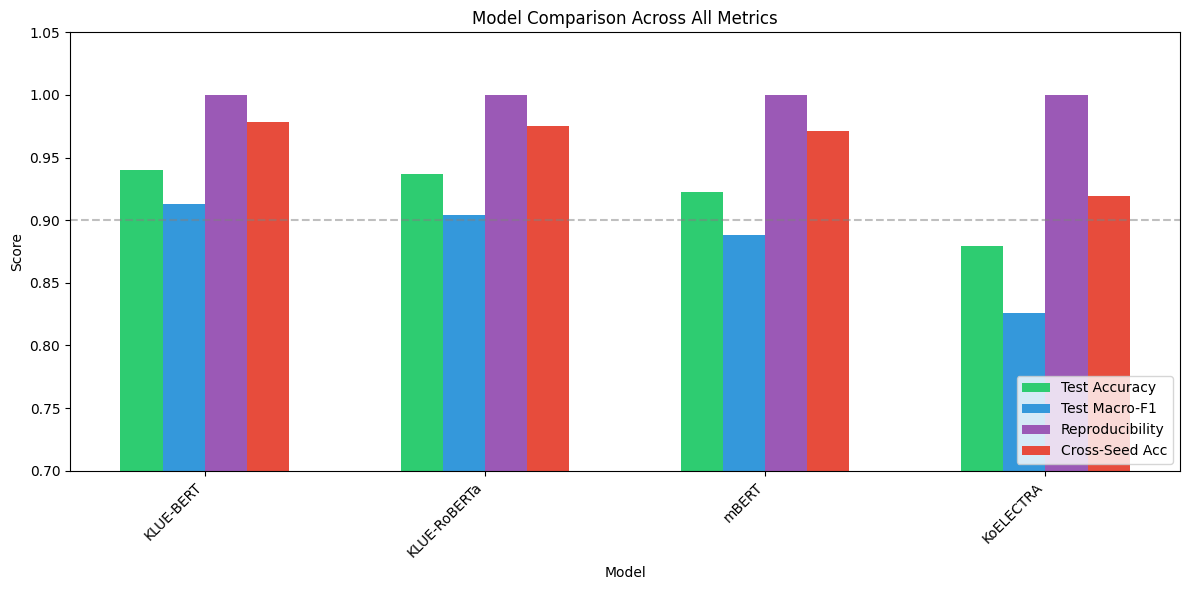

In [76]:
# 3. 모델 종합 비교
fig, ax = plt.subplots(figsize=(12, 6))

models = ranking_df["model"].tolist()
x = np.arange(len(models))
width = 0.15

metrics = [
    ("test_accuracy", "Test Accuracy"),
    ("test_macro_f1", "Test Macro-F1"),
    ("agreement_rate", "Reproducibility"),
    ("cross_seed_acc", "Cross-Seed Acc")
]

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for i, (metric, label) in enumerate(metrics):
    values = ranking_df[metric].tolist()
    ax.bar(x + i * width, values, width, label=label, color=colors[i])

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across All Metrics")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/model_comparison.png", dpi=150)
plt.show()

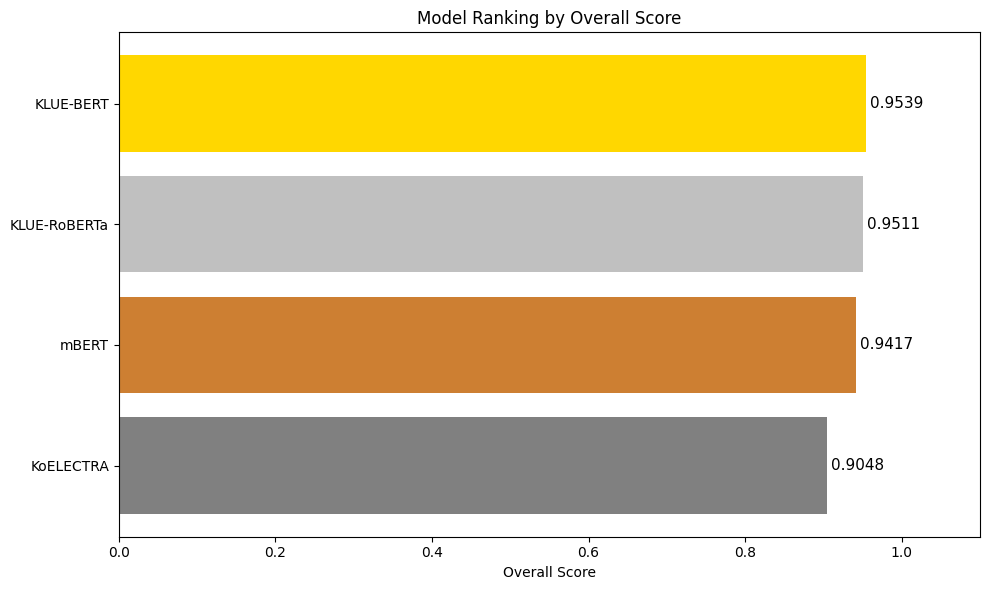

In [77]:
# 4. 종합 점수 랭킹 차트
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['gold', 'silver', '#CD7F32', 'gray']
bars = ax.barh(ranking_df["model"], ranking_df["overall_score"], color=colors)

# 값 표시
for bar, score in zip(bars, ranking_df["overall_score"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=11)

ax.set_xlabel("Overall Score")
ax.set_title("Model Ranking by Overall Score")
ax.set_xlim(0, 1.1)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/model_ranking.png", dpi=150)
plt.show()

### 시각화 5: Same-Seed vs Cross-Seed 성능 비교

같은 seed의 테스트 세트에서의 성능과, 다른 seed의 테스트 세트에서의 성능을 비교합니다.
차이가 작을수록 모델의 일반화 능력이 우수합니다.

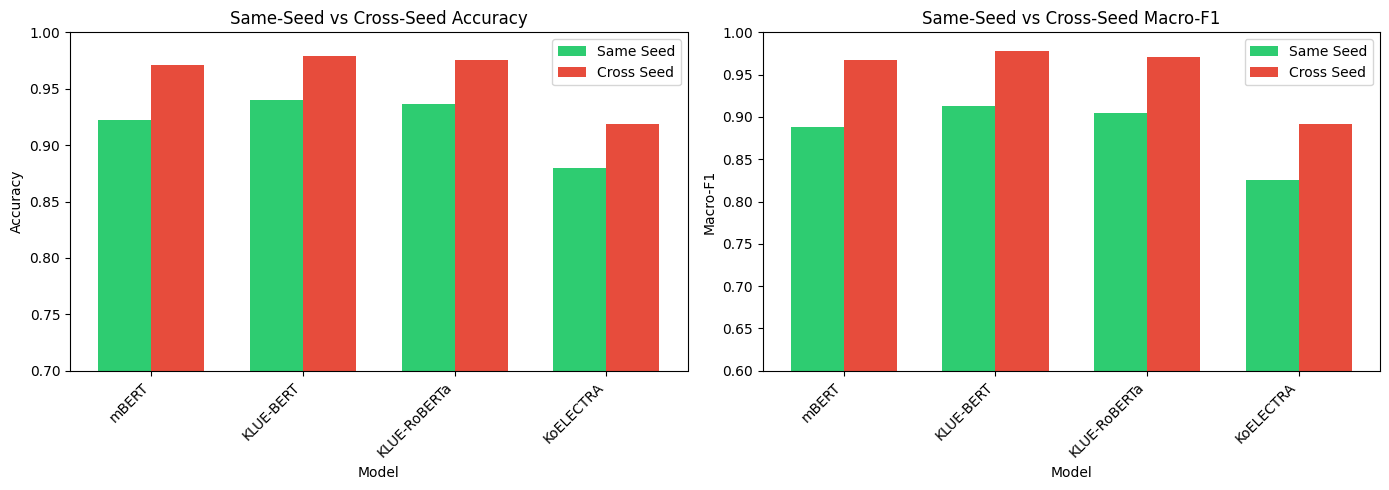

In [78]:
# 5. Same-seed vs Cross-seed 성능 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(CONFIG["models"]))
width = 0.35

# Accuracy
axes[0].bar(x - width/2, comparison_df["same_seed_acc"], width, label='Same Seed', color='#2ecc71')
axes[0].bar(x + width/2, comparison_df["cross_seed_acc"], width, label='Cross Seed', color='#e74c3c')
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Same-Seed vs Cross-Seed Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df["model"], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)

# F1
axes[1].bar(x - width/2, comparison_df["same_seed_f1"], width, label='Same Seed', color='#2ecc71')
axes[1].bar(x + width/2, comparison_df["cross_seed_f1"], width, label='Cross Seed', color='#e74c3c')
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Same-Seed vs Cross-Seed Macro-F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df["model"], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/figures/same_vs_cross_seed.png", dpi=150)
plt.show()

## 11. 실험 설정 저장

실험의 완전한 재현을 위해 모든 설정값을 JSON으로 기록합니다.

In [79]:
# 실험 설정 저장
experiment_info = {
    "experiment_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "config": {
        "seeds": CONFIG["seeds"],
        "models": list(CONFIG["models"].keys()),
        "n_folds": CONFIG["n_folds"],
        "epochs": CONFIG["epochs"],
        "batch_size": CONFIG["batch_size"],
        "learning_rate": CONFIG["learning_rate"],
        "max_length": CONFIG["max_length"],
        "reproducibility_runs": CONFIG["reproducibility_runs"]
    },
    "best_model": {
        "name": best_model["model"],
        "cv_accuracy": float(best_model["cv_accuracy"]),
        "test_accuracy": float(best_model["test_accuracy"]),
        "test_macro_f1": float(best_model["test_macro_f1"]),
        "agreement_rate": float(best_model["agreement_rate"]),
        "cross_seed_acc": float(best_model["cross_seed_acc"]),
        "overall_score": float(best_model["overall_score"])
    },
    "num_labels": NUM_LABELS,
    "device": str(DEVICE)
}

with open(f"{CONFIG['output_dir']}/experiment_info.json", 'w', encoding='utf-8') as f:
    json.dump(experiment_info, f, indent=2, ensure_ascii=False)

print(f"실험 설정이 저장되었습니다: {CONFIG['output_dir']}/experiment_info.json")

실험 설정이 저장되었습니다: ./results/final_experiment/experiment_info.json


## 12. 최종 결론

### 최종 결론 출력

4개 모델(mBERT, KLUE-BERT, KLUE-RoBERTa, KoELECTRA)의 실험 결과를 종합하여,
CV 성능, 재현성, 일반화 능력을 기준으로 최적 모델을 추천합니다.

In [80]:
print("="*70)
print("실험 완료 요약")
print("="*70)

print(f"\n1. 실험 구성:")
print(f"   - 모델: {len(CONFIG['models'])}개 (mBERT, KLUE-BERT, KLUE-RoBERTa, KoELECTRA)")
print(f"   - 데이터 Seed: {len(CONFIG['seeds'])}개 ({CONFIG['seeds']})")
print(f"   - Cross-Validation: Stratified {CONFIG['n_folds']}-Fold")

print(f"\n2. 학습 수행:")
print(f"   - CV 학습: {len(CONFIG['models']) * len(CONFIG['seeds']) * CONFIG['n_folds']}회 (4모델 × 3seeds × 10folds)")
print(f"   - 최종 모델 학습: {len(trained_models)}개")

print(f"\n3. 평가 수행:")
print(f"   - Test Set 평가: {len(test_results_all)}회")
print(f"   - 재현성 테스트: {len(reproducibility_results)}회 (각 3회 반복 예측)")
print(f"   - Cross-Seed 테스트: {len(cross_seed_results)}회")

print(f"\n4. 모델 랭킹:")
for _, row in ranking_df.iterrows():
    print(f"   {int(row['rank'])}위: {row['model']} (종합점수: {row['overall_score']:.4f})")

print(f"\n5. 추천 모델: {best_model['model']}")
print(f"   - CV 정확도: {best_model['cv_accuracy']:.4f}")
print(f"   - Test 정확도: {best_model['test_accuracy']:.4f}")
print(f"   - 재현성: {best_model['agreement_rate']:.4f}")
print(f"   - 일반화: {best_model['cross_seed_acc']:.4f}")

print(f"\n6. 저장된 결과 파일:")
print(f"   - {CONFIG['output_dir']}/cv_results.csv")
print(f"   - {CONFIG['output_dir']}/test_results.csv")
print(f"   - {CONFIG['output_dir']}/reproducibility.csv")
print(f"   - {CONFIG['output_dir']}/cross_seed_generalization.csv")
print(f"   - {CONFIG['output_dir']}/model_ranking.csv")
print(f"   - {CONFIG['output_dir']}/experiment_info.json")
print(f"   - {CONFIG['output_dir']}/figures/ (시각화 7개)")
print(f"   - {CONFIG['output_dir']}/models/ (학습된 모델 12개)")

print("\n" + "="*70)
print("실험 완료")
print("="*70)

실험 완료 요약

1. 실험 구성:
   - 모델: 4개 (mBERT, KLUE-BERT, KLUE-RoBERTa, KoELECTRA)
   - 데이터 Seed: 3개 ([42, 43, 44])
   - Cross-Validation: Stratified 10-Fold

2. 학습 수행:
   - CV 학습: 120회 (4모델 × 3seeds × 10folds)
   - 최종 모델 학습: 12개

3. 평가 수행:
   - Test Set 평가: 12회
   - 재현성 테스트: 12회 (각 3회 반복 예측)
   - Cross-Seed 테스트: 36회

4. 모델 랭킹:
   1위: KLUE-BERT (종합점수: 0.9539)
   2위: KLUE-RoBERTa (종합점수: 0.9511)
   3위: mBERT (종합점수: 0.9417)
   4위: KoELECTRA (종합점수: 0.9048)

5. 추천 모델: KLUE-BERT
   - CV 정확도: 0.9399
   - Test 정확도: 0.9399
   - 재현성: 1.0000
   - 일반화: 0.9788

6. 저장된 결과 파일:
   - ./results/final_experiment/cv_results.csv
   - ./results/final_experiment/test_results.csv
   - ./results/final_experiment/reproducibility.csv
   - ./results/final_experiment/cross_seed_generalization.csv
   - ./results/final_experiment/model_ranking.csv
   - ./results/final_experiment/experiment_info.json
   - ./results/final_experiment/figures/ (시각화 7개)
   - ./results/final_experiment/models/ (학습된 모델 12개)

실험 완료
